<h1><b>function transformer using multiple technique 
       1: Log transform
       2: square transform
       3: Square root transform
       4: np .sin
       5: 1/x using
<b></h1>

In [4]:
import numpy as np
import pandas as pd

import scipy.stats as stats


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv('train.csv')

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df=pd.read_csv('train.csv',usecols=['Survived','Age','Fare'])

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [10]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_9800\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [11]:
df

,Survived,Age,Fare
0,0,22.000000,7.2500
1,1,38.000000,71.2833
2,1,26.000000,7.9250
3,1,35.000000,53.1000
4,0,35.000000,8.0500
...,...,...,...
886,0,27.000000,13.0000
887,1,19.000000,30.0000
888,0,29.699118,23.4500
889,1,26.000000,30.0000


In [12]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [13]:
X=df.iloc[0:,1:3]
y=df.iloc[:,0]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

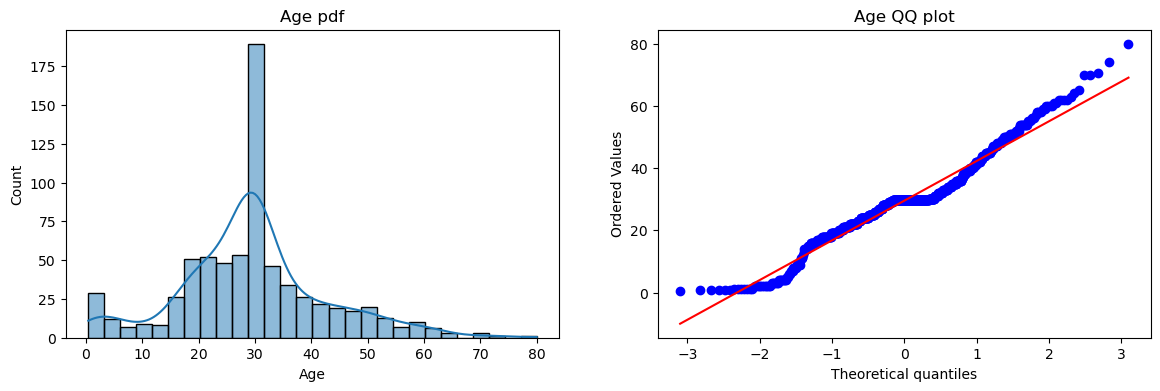

In [15]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ plot')

plt.show()


C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_9800\3426003654.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


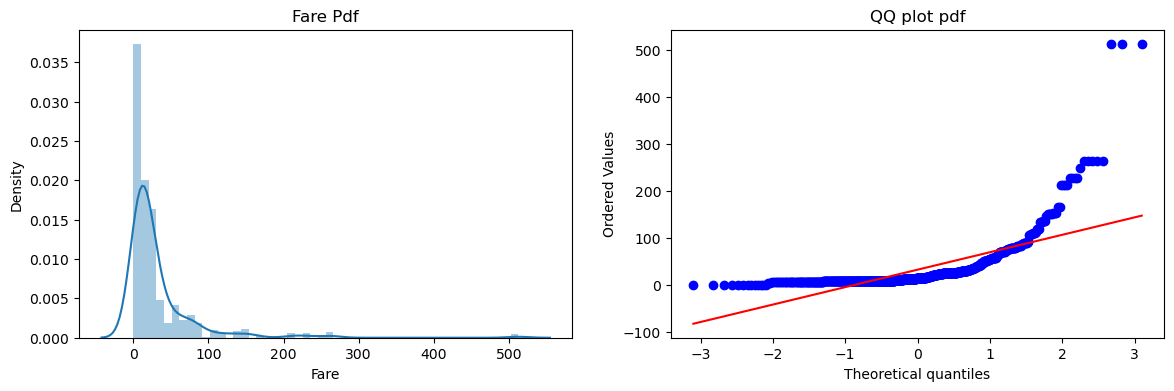

In [16]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare Pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('QQ plot pdf')

plt.show()

In [17]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [18]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

print('LR accuracy',accuracy_score(y_test,y_pred))
print('Dc  accuracy',accuracy_score(y_test,y_pred1))


LR accuracy 0.6480446927374302
Dc  accuracy 0.6536312849162011


In [19]:
trf=FunctionTransformer(func=np.log1p)

In [20]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [21]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)
print('LR accuracy',accuracy_score(y_test,y_pred))
print('Dc  accuracy',accuracy_score(y_test,y_pred1))



LR accuracy 0.6815642458100558
Dc  accuracy 0.6983240223463687


In [22]:
X_transformed= trf.fit_transform(X)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print('Lr accuracy',np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print('Dc accuracy',np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

Lr accuracy 0.678027465667915
Dc accuracy 0.655505617977528


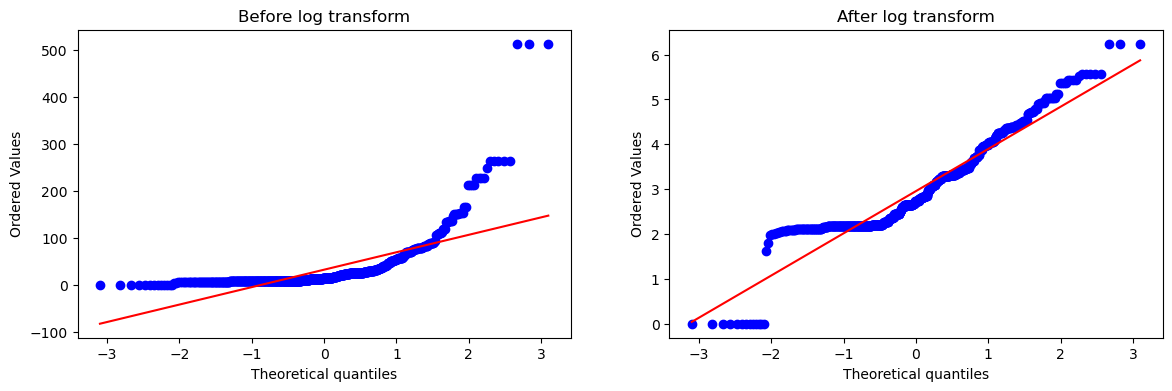

In [23]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Before log transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('After log transform')

plt.show()

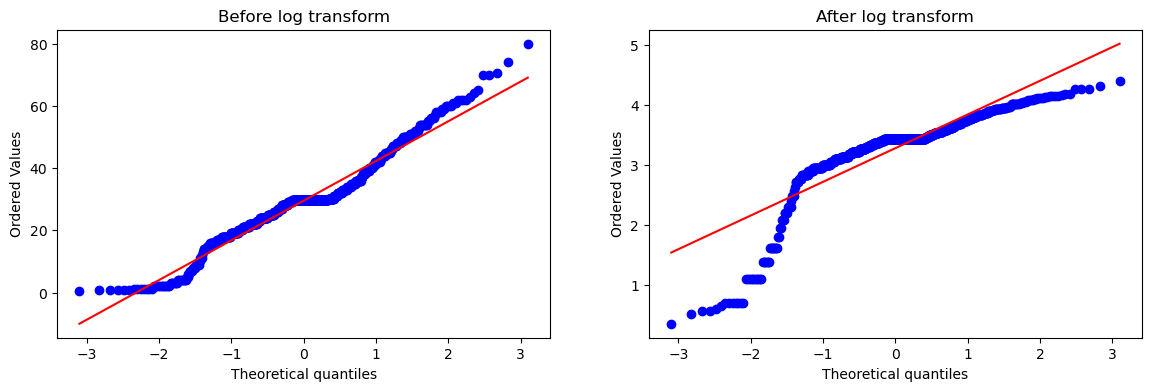

In [24]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Before log transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('After log transform')

plt.show()

In [31]:
trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2= trf2.fit_transform(X_test)



In [32]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))


Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849


In [35]:
X_transformed2=trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('Lr accuracy',np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print('Dc accuracy',np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

Lr accuracy 0.6712609238451936
Dc accuracy 0.6621972534332085


In [48]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()





In [ ]:
apply_transform(lambda X:1/(X+0.1))

Accuracy 0.61729088639201


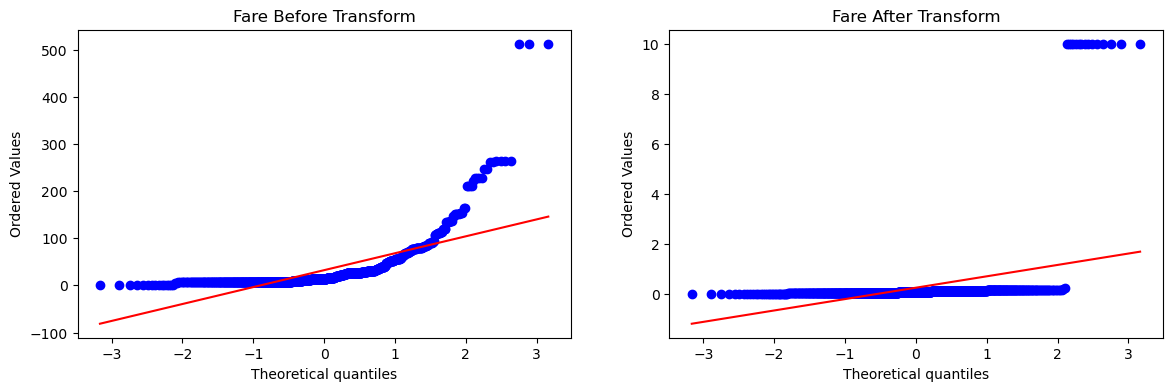

In [59]:
apply_transform(lambda X:1/(X+0.1))

Accuracy 0.6195131086142323


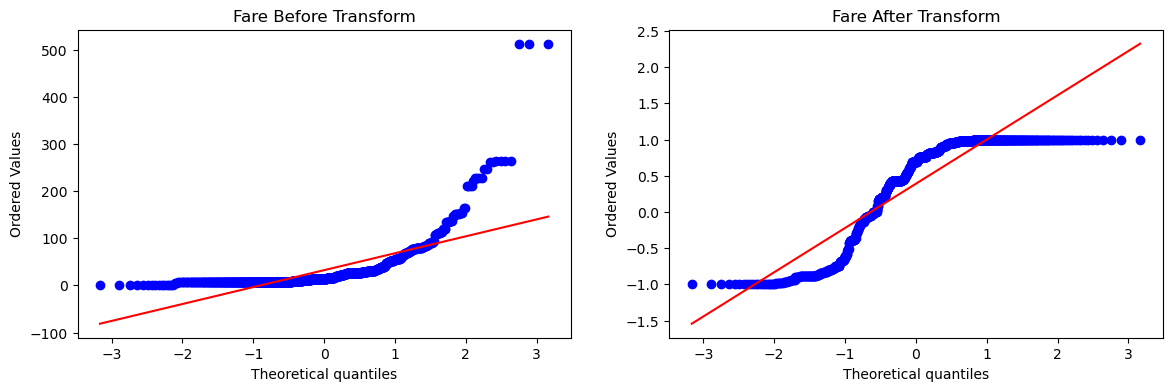

In [62]:
apply_transform(np.sin)